
# Drift — Comparación de estrategias y métricas (Notebook Limpio)

**Objetivo:** evaluar de forma imparcial las 3 **estrategias de referencia** (`decay`, `golden`, `seasonal`) usando **métricas de drift** estándar (Evidently preset, KS, Mann–Whitney, PSI y Wasserstein), **sin etiquetas**.  
El notebook produce:
- Resultados **por planta** y **por estrategia** en carpetas separadas.
- Un **resumen global** consolidado para análisis comparativo entre estrategias y métricas.
- Visualizaciones básicas (heatmaps de tasa de drift, correlación entre métricas, ranking de sensibilidad).
- Texto explicativo listo para reutilizar en informe.

> Este notebook usa funciones de `drift_funcs.py` (no reimplementa métricas a mano).


## 1) Setup

In [24]:

from pathlib import Path
import pandas as pd
import numpy as np

# Importa utilidades del módulo (no métricas personalizadas manuales).
import importlib, sys, json, textwrap, os
drift = importlib.import_module('drift_funcs')

# Comprobación opcional SciPy (para ks/wasserstein/mannwhitney)
HAVE_SCIPY = getattr(drift, '_HAVE_SCIPY', False)
print('SciPy disponible:', HAVE_SCIPY)

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 160)


SciPy disponible: True


## 2) Parámetros del experimento

In [25]:

# === Edita aquí según tus archivos ===
# CSVs de cada planta (con columna 'date_time')
plant_files = {
    'planta1': Path('../df_procesados/df_planta_1.csv'),  # <-- actualiza si corresponde
    'planta2': Path('../df_procesados/df_planta_2.csv'),
    'planta3': Path('../df_procesados/df_planta_3.csv'),
}

# CSVs de flags (opcionales). Deja None si no usas flags para la planta.
flag_files = {
    'planta1': Path('../df_procesados/flags_p1.csv'),  # o None
    'planta2': Path('../df_procesados/flags_p2.csv'),
    'planta3': Path('../df_procesados/flags_p3.csv'),
}

plants = list(plant_files.keys())
strategies = ['decay', 'golden', 'seasonal']
metrics = [ 'ks', 'mannwhitney', 'psi', 'wasserstein']

# Ventanas y muestreos
CURRENT_WINDOW = '3D'
RESAMPLE = None
RESAMPLE_AGG = 'mean'

# Exclusiones (por nombre exacto de columna)
EXCLUDE_COLUMNS = ['pH Ecualizador 2 (Tk 250m3)', "Conductividad DAF", "Temperatura DAF", 
                    'pH entrada a Ecualizador 1', "Flujo Aire Reactor 1", "OD Reactor 1"
]
# Hiperparámetros de estrategias
DECAY_HALF_LIFE_HOURS = 24*7
DECAY_WEIGHT_MASS = 0.95

GOLDEN_WIN = '30min'
GOLDEN_STEP = '10min'
GOLDEN_K = 40

SEASONAL_WEEKS_BACK = 12

NUM_THRESHOLD = None

# Salida
OUTPUT_ROOT = Path('ReportesMetricasDrift')
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
print('Directorio de salida:', OUTPUT_ROOT)


Directorio de salida: ReportesMetricasDrift


## 3) Ejecución batch (HTML Evidently + CSV PSI por estrategia)

In [ ]:

# Ejecuta el batch que genera: HTML Evidently + CSV de métricas (PSI) por planta/estrategia
paths, errors = drift.run_drift_batch(
    plant_names=plants,
    strategies=strategies,
    plant_files=plant_files,
    flag_files=flag_files,
    output_root=OUTPUT_ROOT,
    CURRENT_WINDOW=CURRENT_WINDOW,
    RESAMPLE=RESAMPLE,
    RESAMPLE_AGG=RESAMPLE_AGG,
    EXCLUDE_COLUMNS=EXCLUDE_COLUMNS,
    NUM_METHOD='psi',
    NUM_THRESHOLD=NUM_THRESHOLD,
    DECAY_HALF_LIFE_HOURS=DECAY_HALF_LIFE_HOURS,
    DECAY_WEIGHT_MASS=DECAY_WEIGHT_MASS,
    GOLDEN_WIN=GOLDEN_WIN,
    GOLDEN_STEP=GOLDEN_STEP,
    GOLDEN_K=GOLDEN_K,
    SEASONAL_WEEKS_BACK=SEASONAL_WEEKS_BACK,
    SAVE_HTML=False,
    SAVE_JSON=False,
)

print('\n=== Paths generados ===')
for k, p in paths.items():
    print(k, '->', p)

print('\n=== Errores (si hay) ===')
for k, e in errors.items():
    print(k, '->', e)


[OK] planta1 · decay → planta1_decay.html
[OK] planta1 · golden → planta1_golden.html
[OK] planta1 · seasonal → planta1_seasonal.html
[OK] planta2 · decay → planta2_decay.html
[OK] planta2 · golden → planta2_golden.html
[OK] planta2 · seasonal → planta2_seasonal.html
[OK] planta3 · decay → planta3_decay.html
[OK] planta3 · golden → planta3_golden.html
[OK] planta3 · seasonal → planta3_seasonal.html

=== Paths generados ===
('planta1', 'decay') -> ReportesMetricasDrift\planta1\planta1_decay.html
('planta1', 'golden') -> ReportesMetricasDrift\planta1\planta1_golden.html
('planta1', 'seasonal') -> ReportesMetricasDrift\planta1\planta1_seasonal.html
('planta2', 'decay') -> ReportesMetricasDrift\planta2\planta2_decay.html
('planta2', 'golden') -> ReportesMetricasDrift\planta2\planta2_golden.html
('planta2', 'seasonal') -> ReportesMetricasDrift\planta2\planta2_seasonal.html
('planta3', 'decay') -> ReportesMetricasDrift\planta3\planta3_decay.html
('planta3', 'golden') -> ReportesMetricasDrift


## 4) Comparación de métricas por estrategia

Para cada `strategy` en `{'decay','golden','seasonal'}` calculamos una **tabla por columna** con la métrica solicitada, y un **resumen global** con:
- `n_columns_total`, `n_columns_drifted`, `drift_rate_pct`
- recuento de columnas numéricas/categóricas
- filas en referencia/actual

Esto permite comparar **sensibilidad** de métricas y consistencia entre ellas **sin etiquetas**.


In [27]:

def run_compare_all(plant_name: str, df_path: Path):
    df = pd.read_csv(df_path)
    out_records_cols = []   # granular por columna
    out_records_sum = []    # resumen por métrica

    for strat in strategies:
        for metric in metrics:
            try:
                dfm, overall = drift.compare_with_metric(
                    df=df,
                    strategy=strat,
                    CURRENT_WINDOW=CURRENT_WINDOW,
                    RESAMPLE=RESAMPLE,
                    RESAMPLE_AGG=RESAMPLE_AGG,
                    EXCLUDE_COLUMNS=EXCLUDE_COLUMNS,
                    metric=metric,
                    num_threshold=NUM_THRESHOLD,
                    DECAY_HALF_LIFE_HOURS=DECAY_HALF_LIFE_HOURS,
                    DECAY_WEIGHT_MASS=DECAY_WEIGHT_MASS,
                    GOLDEN_WIN=GOLDEN_WIN,
                    GOLDEN_STEP=GOLDEN_STEP,
                    GOLDEN_K=GOLDEN_K,
                    SEASONAL_WEEKS_BACK=SEASONAL_WEEKS_BACK,
                    save_html=False
                )
                # por columna
                if not dfm.empty:
                    dfm = dfm.copy()
                    dfm['plant'] = plant_name
                    dfm['strategy'] = strat
                    dfm['metric'] = metric
                    out_records_cols.append(dfm)
                # resumen
                rec = dict(overall)
                rec.update({'plant': plant_name, 'strategy': strat, 'metric': metric})
                out_records_sum.append(rec)
            except Exception as e:
                out_records_sum.append({'plant': plant_name, 'strategy': strat, 'metric': metric, 'error': str(e)})

    df_cols = pd.concat(out_records_cols, axis=0, ignore_index=True) if out_records_cols else pd.DataFrame()
    df_sum = pd.DataFrame(out_records_sum)
    return df_cols, df_sum


all_cols, all_sum = [], []
for plant, path in plant_files.items():
    if not path.exists():
        print(f"[WARN] No encontrado: {path}")
        continue
    df_cols, df_sum = run_compare_all(plant, path)
    # Guarda por planta
    plant_dir = OUTPUT_ROOT / plant / '_comparisons'
    plant_dir.mkdir(parents=True, exist_ok=True)
    if not df_cols.empty:
        df_cols.to_csv(plant_dir / f'{plant}_columns_all_metrics.csv', index=False)
    df_sum.to_csv(plant_dir / f'{plant}_summary_all_metrics.csv', index=False)
    all_cols.append(df_cols)
    all_sum.append(df_sum)

# Consolidados globales
df_cols_all = pd.concat([d for d in all_cols if d is not None and not d.empty], ignore_index=True) if all_cols else pd.DataFrame()
df_sum_all  = pd.concat([d for d in all_sum if d is not None and not d.empty],  ignore_index=True) if all_sum  else pd.DataFrame()

df_cols_all_path = OUTPUT_ROOT / 'GLOBAL_columns_all_metrics.csv'
df_sum_all_path  = OUTPUT_ROOT / 'GLOBAL_summary_all_metrics.csv'
if not df_cols_all.empty:
    df_cols_all.to_csv(df_cols_all_path, index=False)
df_sum_all.to_csv(df_sum_all_path, index=False)

df_sum_all.head(20)

,ref_rows,cur_rows,n_columns_total,n_columns_drifted,drift_rate_pct,n_numeric,n_categorical,plant,strategy,metric
0,31666,3580,15,9,60.000000,11,1,planta1,decay,ks
1,31666,3580,15,6,40.000000,11,1,planta1,decay,mannwhitney
2,31666,3580,15,10,66.666667,11,1,planta1,decay,psi
3,31666,3580,15,6,40.000000,11,1,planta1,decay,wasserstein
4,1104,3580,13,12,92.307692,11,1,planta1,golden,ks
5,1104,3580,13,5,38.461538,11,1,planta1,golden,mannwhitney
6,1104,3580,13,11,84.615385,11,1,planta1,golden,psi
7,1104,3580,13,11,84.615385,11,1,planta1,golden,wasserstein
8,453,3580,13,11,84.615385,11,1,planta1,seasonal,ks
9,453,3580,13,5,38.461538,11,1,planta1,seasonal,mannwhitney



## 5) Visualizaciones rápidas (tasa de drift y correlaciones)


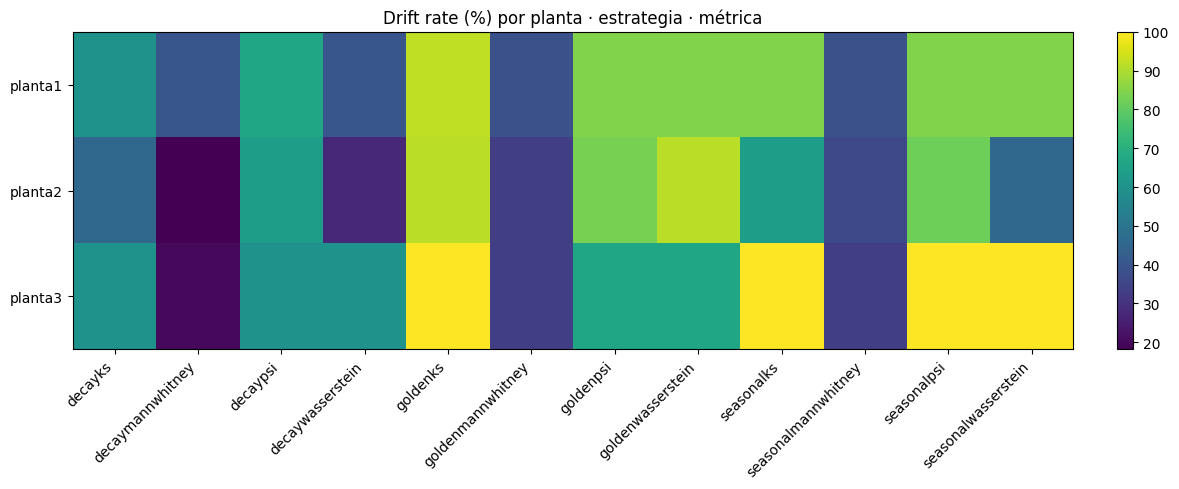

In [32]:

import matplotlib.pyplot as plt

def plot_heatmap_drift_rate(df_summary, title):
    if df_summary.empty:
        print("Sin datos para graficar."); return
    pivot = df_summary.pivot_table(index='plant', columns=['strategy','metric'], values='drift_rate_pct', aggfunc='mean')
    plt.figure(figsize=(12, 5))
    im = plt.imshow(pivot.values, aspect='auto')
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.yticks(range(pivot.shape[0]), pivot.index)
    plt.xticks(range(pivot.shape[1]), [f"{a}{b}" for a,b in pivot.columns], rotation=45, ha='right')
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_heatmap_drift_rate(df_sum_all, "Drift rate (%) por planta · estrategia · métrica")


In [33]:

# Correlación entre métricas (a nivel de columna): ¿aportan señales similares?
if not df_cols_all.empty:
    # Para cada (plant, strategy), correlaciona 'score' entre métricas por columna
    rows = []
    for (pl, strat), sub in df_cols_all.groupby(['plant','strategy']):
        piv = sub.pivot_table(index='col', columns='metric', values='score', aggfunc='mean')
        if piv.shape[1] >= 2 and piv.dropna().shape[0] >= 3:
            cor = piv.corr()
            rows.append({'plant': pl, 'strategy': strat, 'corr_mean': float(cor.where(~np.eye(len(cor),dtype=bool)).stack().mean())})
    corr_df = pd.DataFrame(rows)
    display(corr_df.sort_values(['plant','strategy']))
else:
    print("No hay df_cols_all para correlación.")


,plant,strategy,corr_mean
0,planta1,decay,0.086304
1,planta1,golden,0.095549
2,planta1,seasonal,0.078057
3,planta2,decay,0.256618
4,planta2,golden,0.015002
5,planta2,seasonal,0.205004
6,planta3,decay,0.738964
7,planta3,golden,0.637303
8,planta3,seasonal,0.580801



## 6) Evaluación sin etiquetas (consistencia interna)

Sin *ground truth* se puede evaluar la **consistencia** de la detección:
- **Estabilidad temporal / sensibilidad**: comparar tasas de drift entre métricas; métricas demasiado sensibles (mucho **100%**) o insensibles (**0%**) pueden ser poco útiles.
- **Concordancia entre métricas**: alta correlación de `score` sugiere coherencia (no prueba veracidad, pero indica robustez).
- **Umbrales por percentil**: usar percentiles de la distribución de `score` en referencia histórica para calibrar umbrales.


In [34]:

# Ranking simple de "sensibilidad" por (plant, strategy, metric) usando drift_rate_pct
if not df_sum_all.empty:
    sens = df_sum_all[['plant','strategy','metric','drift_rate_pct']].copy()
    sens['rank_within_plant'] = sens.groupby(['plant','strategy'])['drift_rate_pct'].rank(ascending=False, method='dense')
    display(sens.sort_values(['plant','strategy','rank_within_plant']))
else:
    print("No hay df_sum_all para ranking.")


,plant,strategy,metric,drift_rate_pct,rank_within_plant
2,planta1,decay,psi,66.666667,1.0
0,planta1,decay,ks,60.000000,2.0
1,planta1,decay,mannwhitney,40.000000,3.0
3,planta1,decay,wasserstein,40.000000,3.0
4,planta1,golden,ks,92.307692,1.0
6,planta1,golden,psi,84.615385,2.0
7,planta1,golden,wasserstein,84.615385,2.0
5,planta1,golden,mannwhitney,38.461538,3.0
8,planta1,seasonal,ks,84.615385,1.0
10,planta1,seasonal,psi,84.615385,1.0


In [35]:

# Calibración opcional de umbral por percentil 95 de score (por métrica), como guía
# (No modifica decisiones arriba; sólo reporta valores orientativos)
if not df_cols_all.empty:
    guide = (df_cols_all
             .dropna(subset=['score'])
             .groupby(['plant','strategy','metric'])['score']
             .quantile(0.95)
             .reset_index(name='p95_score'))
    display(guide.sort_values(['plant','strategy','metric']))
else:
    print("No hay df_cols_all para percentiles.")


,plant,strategy,metric,p95_score
0,planta1,decay,ks,0.703211
1,planta1,decay,mannwhitney,0.685100
2,planta1,decay,psi,8.016621
3,planta1,decay,wasserstein,152.138524
4,planta1,golden,ks,2.532447
5,planta1,golden,mannwhitney,2.532447
6,planta1,golden,psi,NaN
7,planta1,golden,wasserstein,196.786289
8,planta1,seasonal,ks,2.505178
9,planta1,seasonal,mannwhitney,2.508261



## 7) Estructura de carpetas de salida

- `reportes_Drift/PLANTA/STRATEGY.html` → Evidently HTML
- `reportes_Drift/PLANTA/PLANTA_STRATEGY_metrics.csv` → métricas PSI por columna
- `reportes_Drift/PLANTA/_comparisons/PLANTA_columns_all_metrics.csv` → todos los scores por columna
- `reportes_Drift/PLANTA/_comparisons/PLANTA_summary_all_metrics.csv` → resumen por métrica
- `reportes_Drift/GLOBAL_columns_all_metrics.csv` → consolidado global por columna
- `reportes_Drift/GLOBAL_summary_all_metrics.csv` → consolidado global por métrica



## 8) Texto explicativo (copiable a informe)

**Estrategias de referencia**  
- **Decay**: pondera por recencia con semivida (\(t_{1/2}\)) y toma el prefijo de mayor masa acumulada (p. ej., 95%). Útil si el proceso cambia lentamente con el tiempo.
- **Golden**: recorre ventanas fijas y selecciona los **k** intervalos más estables (menor variación relativa) para construir una referencia robusta; útil cuando hay tramos "buenos" mezclados con ruido.
- **Seasonal**: usa históricos del mismo *slot* semanal (día/hora) varias semanas hacia atrás; útil ante estacionalidad marcada.

**Métricas de drift (sin etiquetas)**  
- **Evidently (preset)**: aplica pruebas estadísticas y reporta `drift_detected` y `drift_score` por columna.
- **KS (numérica)**: diferencia máxima de distribuciones acumuladas (escala 0–1).
- **Mann–Whitney U (numérica)**: compara si una muestra tiende a valores mayores que la otra (normalizado por tamaño m·n).
- **PSI (numérica/categórica)**: comparación de proporciones por bins/categorías (umbral guía 0.2–0.3).
- **Wasserstein (numérica)**: distancia de transporte; requiere **calibrar** umbral relativo (p. ej., 0.5·σ_ref).

**Evaluación sin ground truth**  
1. **Sensibilidad**: compara `drift_rate_pct` entre métricas; evita extremos sistemáticos (0% o 100%).  
2. **Concordancia**: inspecciona `corr_mean` entre scores para verificar coherencia.  
3. **Calibración**: usa percentiles (p95) de `score` por métrica como guía de umbral operativo.

> Recomendación práctica: fijar umbrales iniciales por métrica y planta (ver p95), revisar falsos positivos/negativos con expertos de proceso y ajustar.
